In [1]:
#3-34 라이브러리 호출
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN #밀도 기반 군집 분석
from sklearn.preprocessing import StandardScaler #평균 0, 표준편차 1로 바꿔주는 라이브러리 (-> 평균으로 부터 각 데이터가 얼마나 떨어져있나를 정리해주는)
from sklearn.preprocessing import normalize #방향만 남기는 (정규화)
from sklearn.decomposition import PCA #주성분 분석, 데이터 차원 축소

In [2]:
#3-35 데이터 불러오기
X = pd.read_csv('./data/credit card.csv')
X = X.drop('CUST_ID', axis=1) #불러온 데이터에서 CUST_ID 열(컬럼) 삭제 (axis=1 : 열)
X.ffill().bfill() #결측 값을 앞의 값으로 채움 (이전 행의 값)
X = X.fillna(X.mean(numeric_only=True)) #normalize()가 NAN을 통과시키지 않음
print(X.head()) #데이터셋 형태 확인

       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                          0.000000   
2                

In [6]:
#3-36 데이터 전처리 및 데이터를 2차원으로 차원 축소
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #평균이 0, 표준편차가 1이 되도록 데이터 크기 조정

X_normalized = normalize(X_scaled) #데이터가 가우스 분포(정규 분포)를 따르도록 정규화
X_normalized = pd.DataFrame(X_normalized) #넘파일 배열을 데이터프레임(dataframe)으로 변환

pca = PCA(n_components=2) #2차원으로 차원 축소 선언
X_principal = pca.fit_transform(X_normalized) #차원 축소 적용
X_principal = pd.DataFrame(X_principal)
X_principal.columns = ['P1', 'P2']
print(X_principal.head())

         P1        P2
0 -0.489826 -0.679678
1 -0.518791  0.545011
2  0.330885  0.268978
3 -0.482374 -0.092111
4 -0.563289 -0.481915


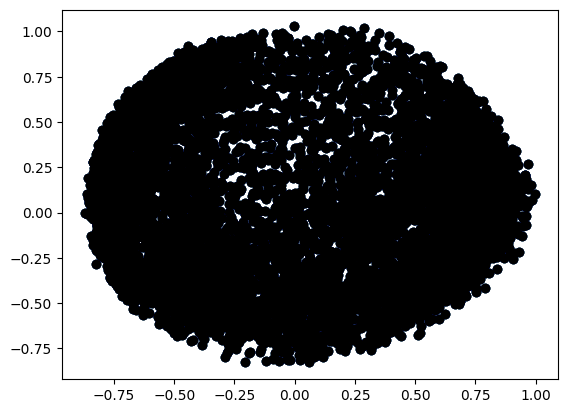

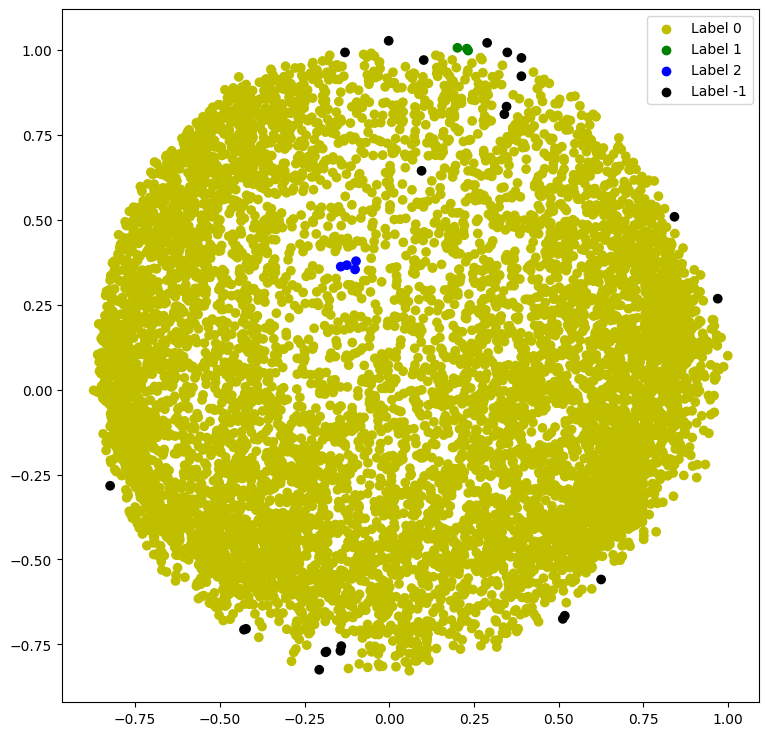

In [8]:
#3-37 DBSCAN(밀도 기반 군집 분석) 모델 생성 및 결과의 시각화
db_default = DBSCAN(eps=0.0375, min_samples=3).fit(X_principal) #모델 생성 및 훈련
labels = db_default.labels_ #각 데이터 포인트에 할당된 모든 클러스터 레이블의 넘파일 배열을 labels에 저장 (*labels_ : 모델이 만든 결과) *데이터 수만큼 한 행에 나열

colours = {} #출력 그래프의 색상을 위한 레이블(정답지) 생성
colours[0] = 'y'
colours[1] = 'g'
colours[2] = 'b'
colours[-1] = 'k'

cvec = [colours[label] for label in labels] #각 데이터 포인트에 대한 색상 벡터 생성(데이터 수만큼 반복)

#색상을 지정했으나 실제로는 X
r = plt.scatter(X_principal['P1'], X_principal['P2'], color='y');
g = plt.scatter(X_principal['P1'], X_principal['P2'], color='g');
b = plt.scatter(X_principal['P1'], X_principal['P2'], color='b');
k = plt.scatter(X_principal['P1'], X_principal['P2'], color='k'); #플롯(plot)의 범례(legend) 생성

plt.figure(figsize=(9,9)) #새로 작성 
plt.scatter(X_principal['P1'], X_principal['P2'], c=cvec) #정의된 색상 벡터에 따라 X축에 P1, Y축에 P2 플로팅(plotting)
plt.legend((r, g, b, k), ('Label 0', 'Label 1', 'Label 2', 'Label -1'))
plt.d()

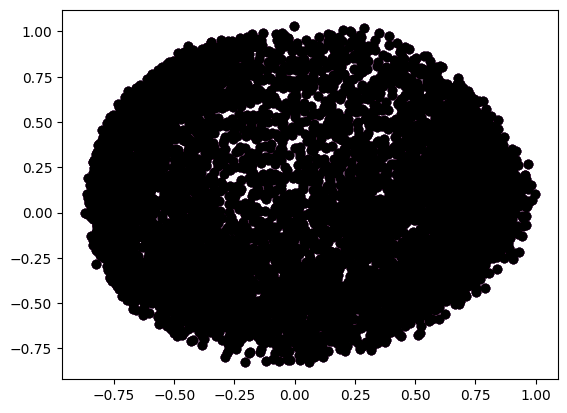

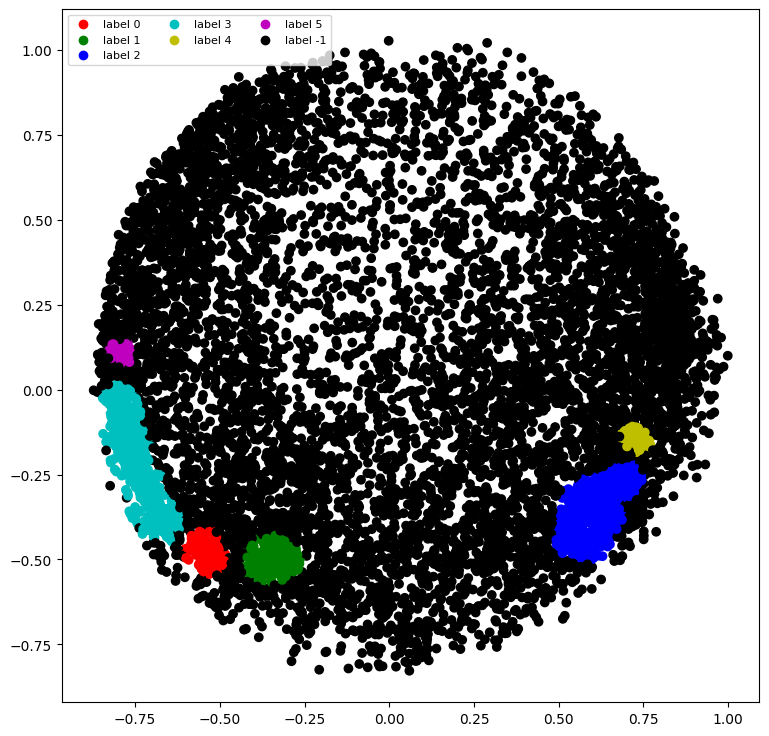

In [14]:
#3-38 모델 튜닝
db = DBSCAN(eps=0.0375, min_samples=50).fit(X_principal)
lebels1 = db.labels_

colours1 = {}
colours1[0] = 'r'
colours1[1] = 'g'
colours1[2] = 'b'
colours1[3] = 'c'
colours1[4] = 'y'
colours1[5] = 'm'
colours1[-1] = 'k' # DBSCAN을 쓰는 한 -1(노이즈)은 거의 항상 나와서 필요 

cvec = [colours1[label] for label in lebels1]
colors1 = ['r', 'g', 'b', 'c', 'y', 'm', 'k']

r = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[0])
g = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[1])
b = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[2])
c = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[3])
y = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[4])
m = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[5])
k = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[6])

plt.figure(figsize=(9,9))
plt.scatter(X_principal['P1'], X_principal['P2'], c=cvec)
plt.legend((r, g, b, c, y, m, k), ('label 0', 'label 1', 'label 2', 'label 3', 'label 4', 'label 5',  'label -1'), scatterpoints=1,
           loc='upper left', ncol=3, fontsize=8) #범례 3개의 열로 배치하고 왼쪽 위에 배치 
plt.show()

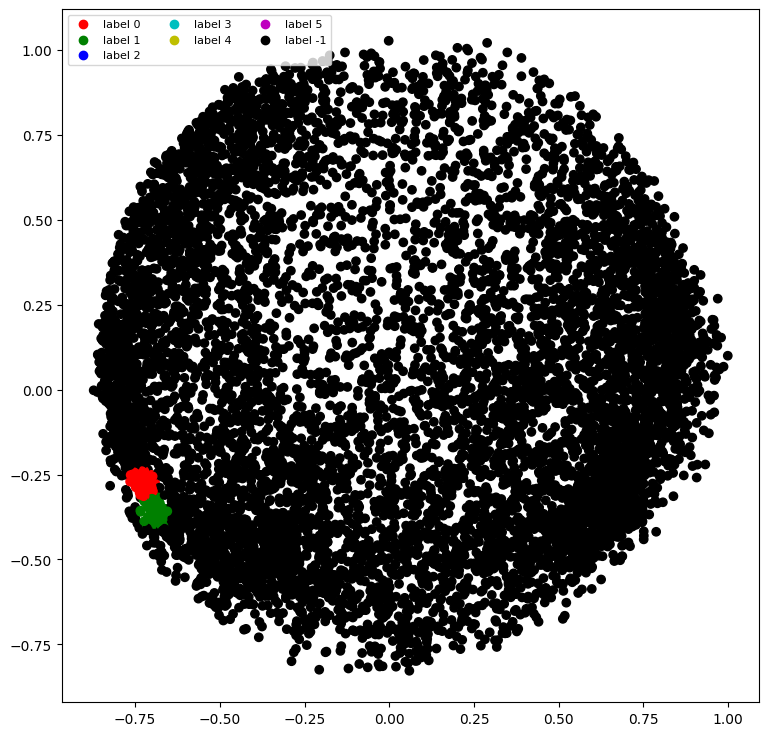

In [19]:
#3-39 min_samples를 50에서 100으로 변경
db = DBSCAN(eps=0.0375, min_samples=100).fit(X_principal) #0.0375반경 내에 100개 이상의 데이터가 있으면 군집으로 구성 (화면 표출)
lebels1 = db.labels_

colours1 = {}
colours1[0] = 'r'
colours1[1] = 'g'
colours1[2] = 'b'
colours1[3] = 'c'
colours1[4] = 'y'
colours1[5] = 'm'
colours1[-1] = 'k' # DBSCAN을 쓰는 한 -1(노이즈)은 거의 항상 나와서 필요 

cvec = [colours1[label] for label in lebels1]
colors1 = ['r', 'g', 'b', 'c', 'y', 'm', 'k']

plt.figure(figsize=(9,9))
plt.scatter(X_principal['P1'], X_principal['P2'], c=cvec)
plt.legend((r, g, b, c, y, m, k), ('label 0', 'label 1', 'label 2', 'label 3', 'label 4', 'label 5',  'label -1'), scatterpoints=1,
           loc='upper left', ncol=3, fontsize=8) #범례 3개의 열로 배치하고 왼쪽 위에 배치 
plt.show()